#### Supervised ML Project

# Medical Insurance Cost Prediction
---

### Objective:

    Can you accurately predict medical insurance costs based on patient data? In this project, you’ll build various regression models and compare their performance to recommend the best one to the stakeholders.


**Tasks:**

### 1. Import and Load the Data

    •	Import required libraries (pandas, numpy, matplotlib, seaborn, sklearn, etc.)

    •	Load the dataset and explore the structure using .head(), .info() and .describe()

---


In [92]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid', palette='muted')

# --- Preprocessing ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# --- Models ---
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

# --- Evaluation & Tuning ---
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score

print('All libraries imported successfully.')

All libraries imported successfully.


In [93]:
df = pd.read_csv('Medical_Insurance.csv')

df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


In [9]:
cat_cols = ['sex', 'smoker', 'region']
for col in cat_cols:
    print(f'\n{col.upper()}:')
    print(df[col].value_counts())


SEX:
sex
male      676
female    662
Name: count, dtype: int64

SMOKER:
smoker
no     1064
yes     274
Name: count, dtype: int64

REGION:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


### 2. Exploratory Data Analysis (EDA)

    •	Visualize the distribution of each feature
   
    •	Understand correlations (especially with the target variable)

    •	Check for variables distributions.

    •	Summarize insights from EDA


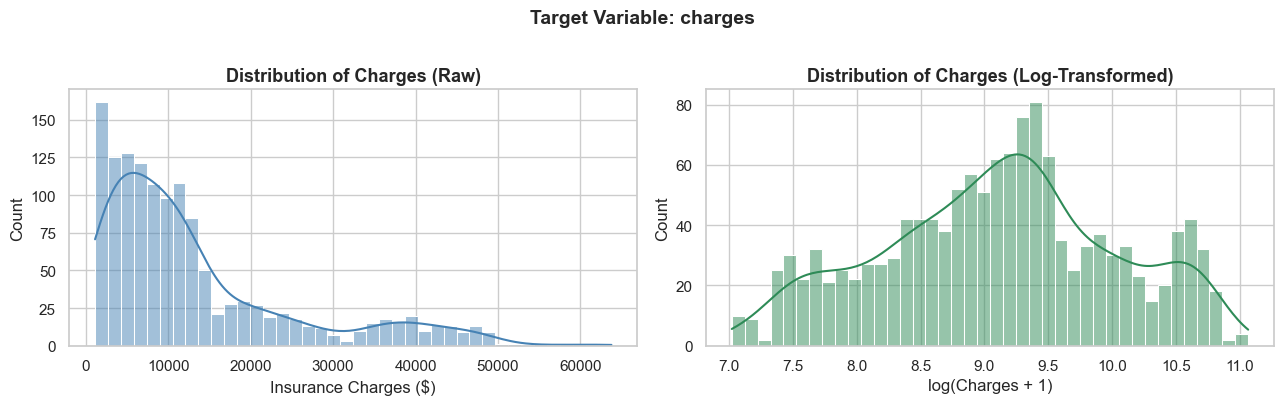

Skewness (raw):          1.516
Skewness (log-transform): -0.090


In [14]:
sns.set_theme(style='whitegrid', palette='muted')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df['charges'], kde=True, ax=axes[0], color='steelblue', bins=40)
axes[0].set_title('Distribution of Charges (Raw)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Insurance Charges ($)')

sns.histplot(np.log1p(df['charges']), kde=True, ax=axes[1], color='seagreen', bins=40)
axes[1].set_title('Distribution of Charges (Log-Transformed)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(Charges + 1)')

plt.suptitle('Target Variable: charges', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Skewness (raw):          {df["charges"].skew():.3f}')
print(f'Skewness (log-transform): {np.log1p(df["charges"]).skew():.3f}')

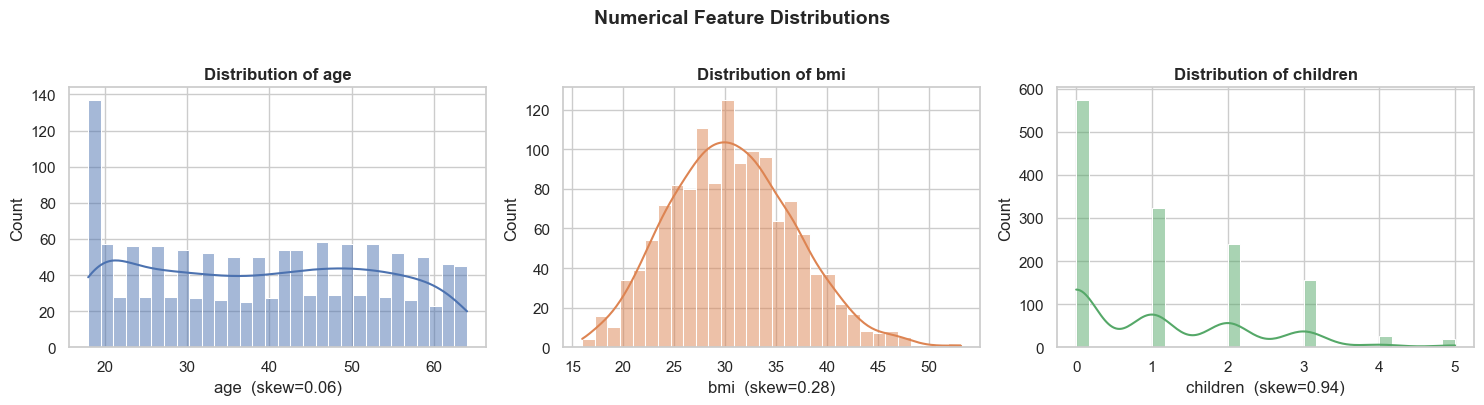

In [17]:
# numerical distribution

num_cols = ['age', 'bmi', 'children']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, (col, color) in enumerate(zip(num_cols, colors)):
    sns.histplot(df[col], kde=True, ax=axes[i], color=color, bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    sk = df[col].skew()
    axes[i].set_xlabel(f'{col}  (skew={sk:.2f})')

plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

> - **`age`**: Near-uniform distribution (skew ≈ 0.06) - no transformation needed.
> - **`bmi`**: Approximately normal (skew ≈ 0.28) - no transformation needed.
> - **`children`**: Discrete, right-skewed - will treat as ordinal integer.

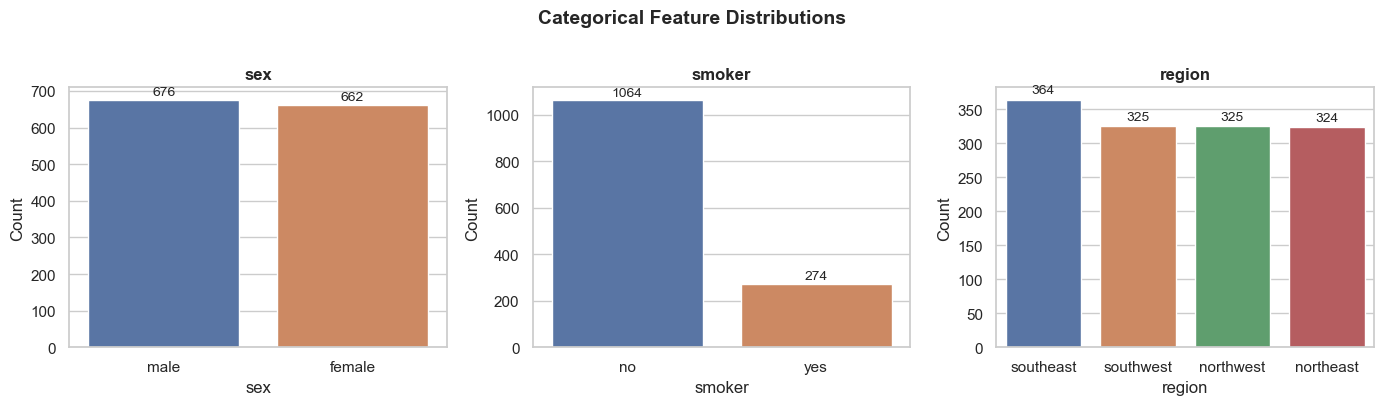

In [18]:
# Categorical distribution

cat_cols = ['sex', 'smoker', 'region']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i], palette=palette[:len(counts)])
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Count')
    for bar, val in zip(axes[i].patches, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                     str(val), ha='center', va='bottom', fontsize=10)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

> - **`sex`**: Balanced (676 male / 662 female) - no class imbalance concern.
> - **`smoker`**: Imbalanced - 79% non-smoker, 21% smoker. Small group but likely high-impact.
> - **`region`**: Evenly distributed across all 4 US regions.

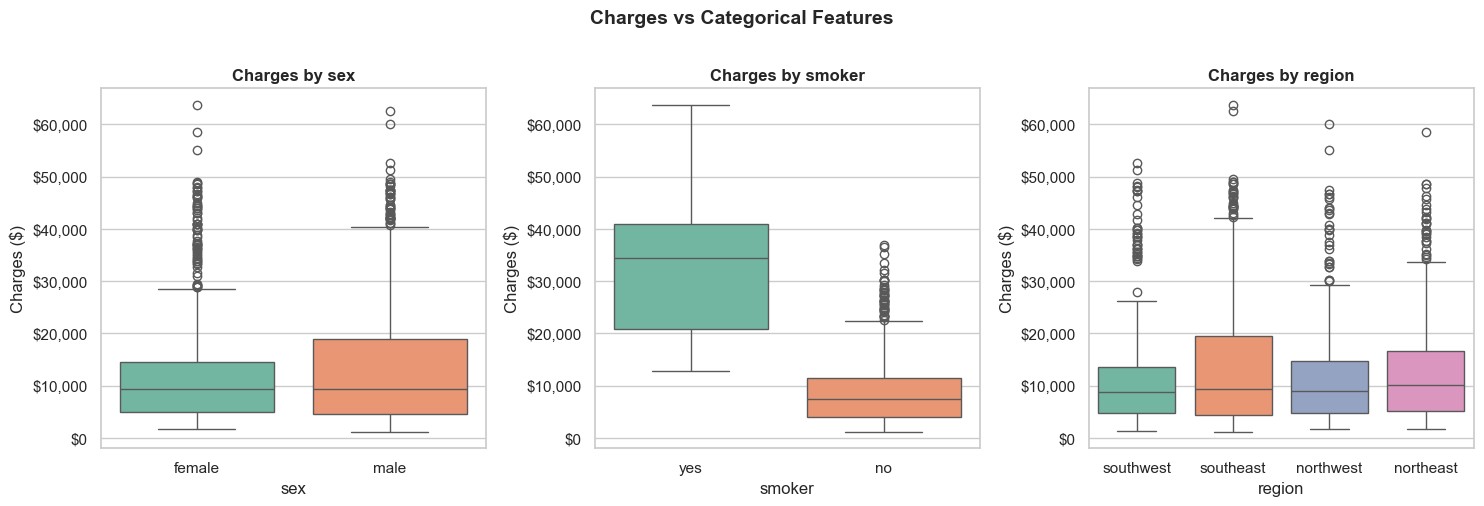

Mean charges by smoker status:
smoker
no      $8,434
yes    $32,050
Name: charges, dtype: object


In [19]:
# Charges vs Categorical Features

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    sns.boxplot(data=df, x=col, y='charges', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Charges by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Charges ($)')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Charges vs Categorical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Mean charges by smoker status:')
print(df.groupby('smoker')['charges'].mean().apply(lambda x: f'${x:,.0f}'))

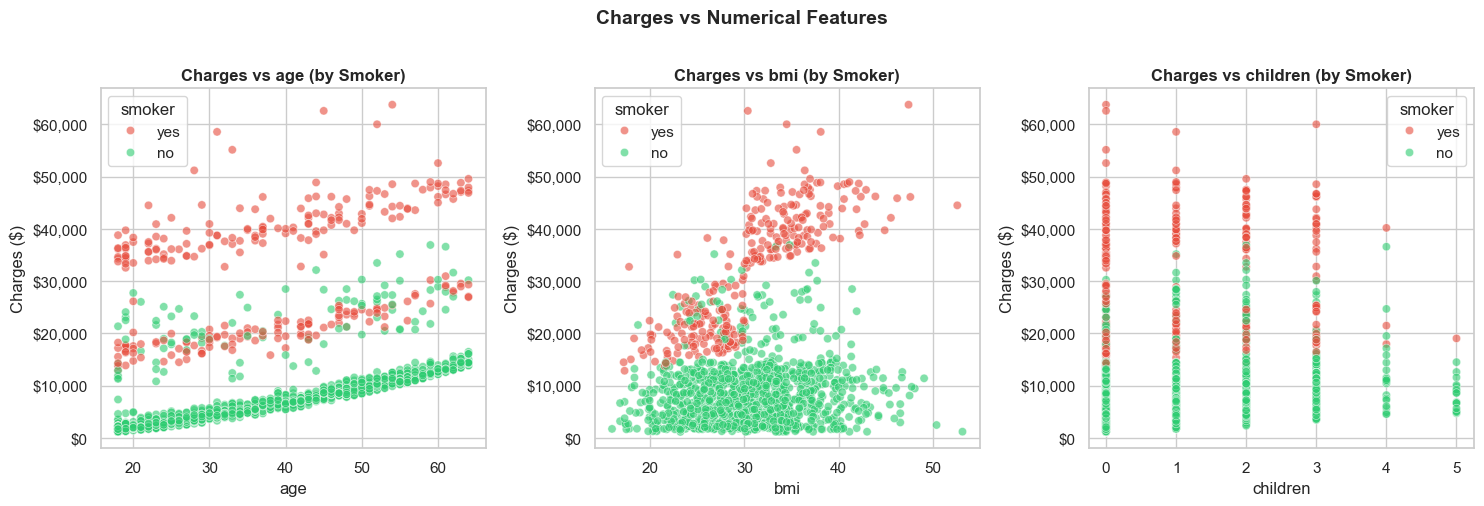

In [20]:
# Charges vs Numerical Features

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_cols):
    sns.scatterplot(data=df, x=col, y='charges', hue='smoker',
                    palette={'yes': '#e74c3c', 'no': '#2ecc71'}, alpha=0.6, ax=axes[i])
    axes[i].set_title(f'Charges vs {col} (by Smoker)', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Charges ($)')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Charges vs Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

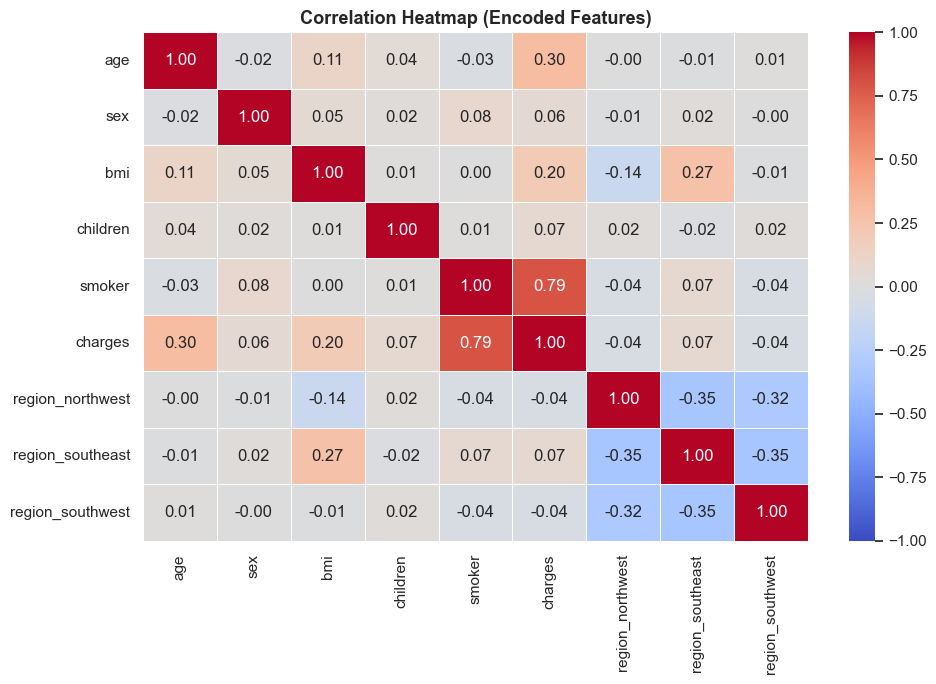


Correlation with charges (sorted):
charges             1.000
smoker              0.787
age                 0.299
bmi                 0.198
region_southeast    0.074
children            0.068
sex                 0.057
region_northwest   -0.040
region_southwest   -0.043
Name: charges, dtype: float64


In [22]:
# correlation

df_enc = df.copy()
df_enc['sex']    = (df_enc['sex']    == 'male').astype(int)
df_enc['smoker'] = (df_enc['smoker'] == 'yes').astype(int)
df_enc = pd.get_dummies(df_enc, columns=['region'], drop_first=True)

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(df_enc.corr(), dtype=bool))
sns.heatmap(df_enc.corr().round(2), annot=True, fmt='.2f', cmap='coolwarm',
             ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap (Encoded Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelation with charges (sorted):')
print(df_enc.corr()['charges'].sort_values(ascending=False).round(3))

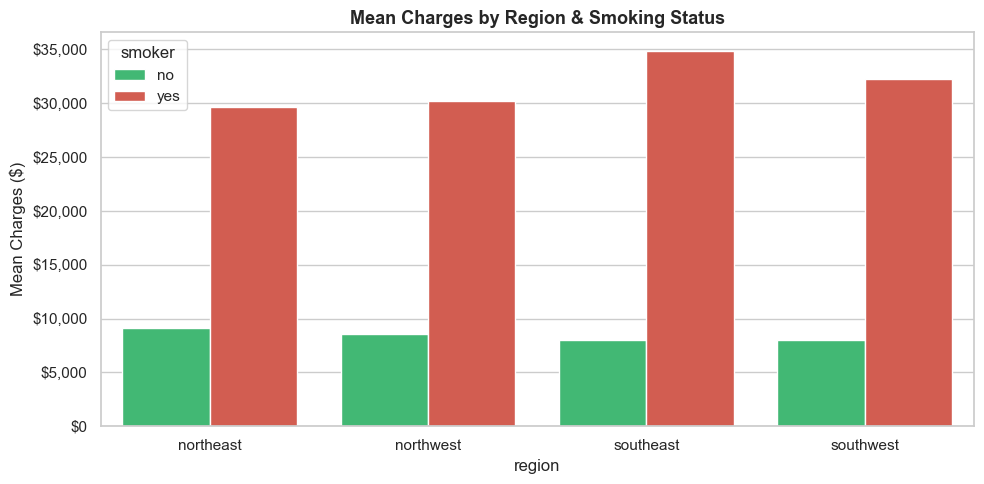

In [23]:
pivot = df.groupby(['region', 'smoker'])['charges'].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=pivot, x='region', y='charges', hue='smoker',
            palette={'yes': '#e74c3c', 'no': '#2ecc71'}, ax=ax)
ax.set_title('Mean Charges by Region & Smoking Status', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Charges ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

 **Across all regions, smokers pay substantially more. The smoking effect is consistent and dominant; region alone adds minimal variance.**

---

### EDA Summary

| Finding | Action |
|---|---|
| `charges` is right-skewed (skew=1.52) | Apply log-transform in preprocessing |
| `smoker` is the dominant predictor (r=0.787) | Retain; consider interaction term with bmi |
| Two clear charge bands (smoker vs non-smoker) | Confirmed non-linear structure → tree models expected to excel |
| `bmi × smoker` interaction visible in scatterplot | Engineer this feature in Step 4 |
| No missing values, no multicollinearity | No imputation needed; all features usable |
| `sex` and `region` low correlation | Include but expect low feature importance |

### 3. Missing Values & Outlier Treatment

    •	Check for missing values and treat them if any

    •	Check if there are anu outliers.

---


In [25]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [27]:
# Outlier - IQR

numerical_cols = ['age', 'bmi', 'children', 'charges']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
    print(f'  Fences: [{lower:.2f}, {upper:.2f}]  |  Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')
    print()

age: Q1=27.00, Q3=51.00, IQR=24.00
  Fences: [-9.00, 87.00]  |  Outliers: 0 (0.00%)

bmi: Q1=26.30, Q3=34.69, IQR=8.40
  Fences: [13.70, 47.29]  |  Outliers: 9 (0.67%)

children: Q1=0.00, Q3=2.00, IQR=2.00
  Fences: [-3.00, 5.00]  |  Outliers: 0 (0.00%)

charges: Q1=4740.29, Q3=16639.91, IQR=11899.63
  Fences: [-13109.15, 34489.35]  |  Outliers: 139 (10.39%)



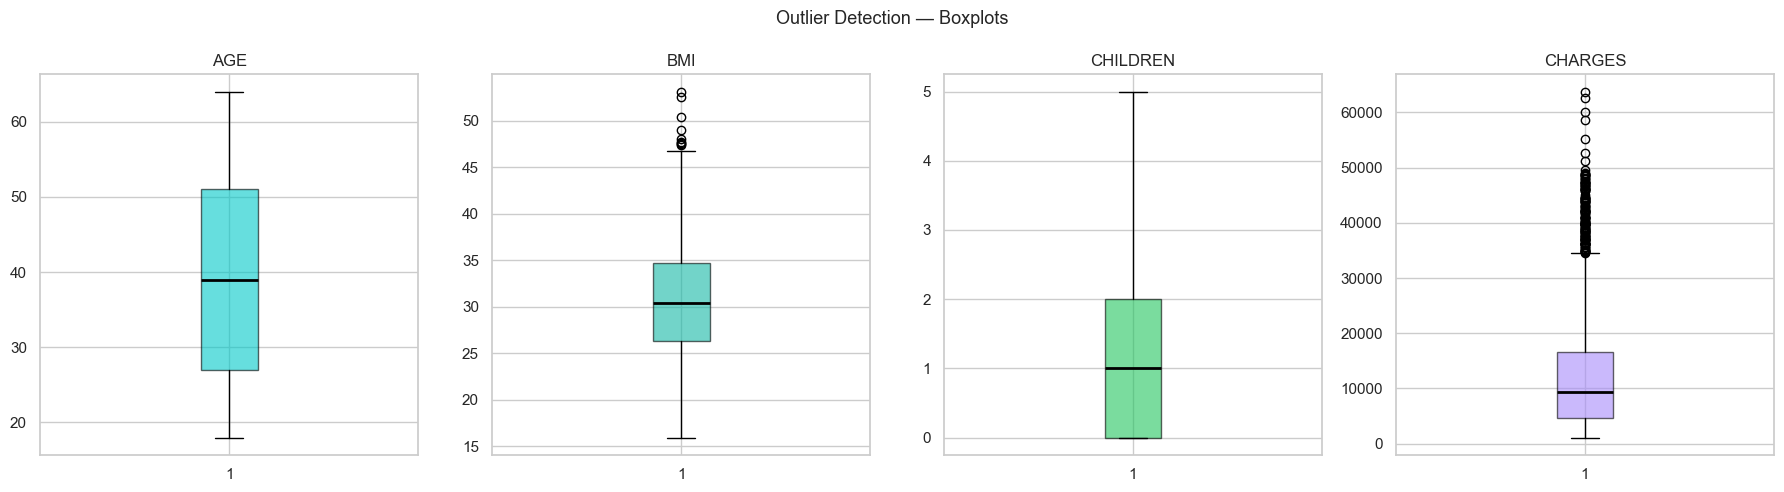

In [28]:
# Outlier - Boxplot

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = ['#00c8c8','#14B8A6','#22C55E','#A78BFA']
for i, (col, color) in enumerate(zip(numerical_cols, colors)):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(col.upper())
plt.suptitle('Outlier Detection — Boxplots', fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
# Outlier Treatment Decision:
# age      - No outliers detected
# bmi      - Retained (clinically valid — obese patients are real)
# children - Retained (count data, max=5 is valid)
# charges  - Retained + apply log transform to reduce skew

print(f'charges skew (raw):   {df["charges"].skew():.3f}')
df['log_charges'] = np.log1p(df['charges'])
print(f'charges skew (log):   {df["log_charges"].skew():.3f}')


charges skew (raw):   1.516
charges skew (log):   -0.090


### 4. Feature Engineering & Preprocessing

    •	Encode categorical variables (sex, smoker, region)

    •	Feature scaling for numerical values (StandardScaler / MinMaxScaler)

    •	Check for skewness and treat it if required.
---

In [97]:
# ── 4.1 Load data and create log_charges ─────────────────────────
df = pd.read_csv('Medical_Insurance.csv')
df['log_charges'] = np.log1p(df['charges'])

print("Skewness check:")
for col in ['age', 'bmi', 'children', 'charges', 'log_charges']:
    print(f"  {col:15s}  skew = {df[col].skew():.3f}")
print()

# ── 4.2 Encode categorical variables ─────────────────────────────
le_sex    = LabelEncoder()
le_smoker = LabelEncoder()
df['sex']    = le_sex.fit_transform(df['sex'])       # female=0, male=1
df['smoker'] = le_smoker.fit_transform(df['smoker']) # no=0, yes=1
df = pd.get_dummies(df, columns=['region'], drop_first=True)

print("Columns after encoding:", df.columns.tolist())
print()

# ── 4.3 Define X and y ───────────────────────────────────────────
X = df.drop(columns=['charges', 'log_charges']).astype(float)
y = df['log_charges']

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Features: {X.columns.tolist()}")
print()

# ── 4.4 Train / Test Split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print()

# ── 4.5 Feature Scaling (fit on train only) ──────────────────────
scaler = StandardScaler()
scale_cols = ['age', 'bmi', 'children']
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

print("After scaling — X_train stats:")
print(X_train[scale_cols].describe().round(3))
print()

Skewness check:
  age              skew = 0.056
  bmi              skew = 0.284
  children         skew = 0.938
  charges          skew = 1.516
  log_charges      skew = -0.090

Columns after encoding: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'log_charges', 'region_northwest', 'region_southeast', 'region_southwest']

X shape : (1338, 8)
y shape : (1338,)
Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']

Training set : (1070, 8)
Test set     : (268, 8)

After scaling — X_train stats:
            age       bmi  children
count  1070.000  1070.000  1070.000
mean     -0.000    -0.000    -0.000
std       1.000     1.000     1.000
min      -1.518    -2.417    -0.911
25%      -0.878    -0.721    -0.911
50%       0.010    -0.058    -0.088
75%       0.828     0.652     0.734
max       1.752     3.736     3.203



### 5. Model Building: Try Multiple Regressors

**Use all the regression-based models to train and test the data:**

    •	Linear Regression
    •	Decision Tree Regressor
    •	Random Forest Regressor
    •	SVR
    •	KNN
    •	Ensemble Learning methods
---

In [98]:
models = {
    'Linear Regression':  LinearRegression(),
    'Decision Tree':       DecisionTreeRegressor(random_state=42),
    'Random Forest':       RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=100, random_state=42),
    'AdaBoost':            AdaBoostRegressor(n_estimators=100, random_state=42),
    'SVR':                 SVR(kernel='rbf'),
    'KNN':                 KNeighborsRegressor(n_neighbors=5),
    'XGBoost':             XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
}

rows = []

for name, model in models.items():
    model.fit(X_train, y_train)

    yp_train = model.predict(X_train)
    yp_test  = model.predict(X_test)

    train_r2 = r2_score(y_train, yp_train)
    test_r2  = r2_score(y_test,  yp_test)
    n, p     = len(X_test), X_test.shape[1]
    adj_r2   = 1 - (1 - test_r2) * (n - 1) / (n - p - 1)
    mae      = mean_absolute_error(y_test,  yp_test)
    mse      = mean_squared_error(y_test,   yp_test)
    rmse     = np.sqrt(mse)
    mae_usd  = mean_absolute_error(np.expm1(y_test), np.expm1(yp_test))
    rmse_usd = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(yp_test)))

    rows.append({
        'Model':    name,
        'Train R2': round(train_r2, 4),
        'Test R2':  round(test_r2,  4),
        'Adj R2':   round(adj_r2,   4),
        'MAE':      round(mae,       4),
        'MSE':      round(mse,       4),
        'RMSE':     round(rmse,      4),
        'MAE ($)':  round(mae_usd,   2),
        'RMSE ($)': round(rmse_usd,  2),
        'Gap':      round(train_r2 - test_r2, 4),
    })

results = pd.DataFrame(rows)
print("All models trained.")
results.sort_values('Test R2', ascending=False)

All models trained.


,Model,Train R2,Test R2,Adj R2,MAE,MSE,RMSE,MAE ($),RMSE ($),Gap
3,Gradient Boosting,0.8768,0.8655,0.8613,0.1873,0.1209,0.3477,2035.42,4388.89,0.0113
5,SVR,0.8357,0.8538,0.8493,0.1641,0.1314,0.3625,2315.24,5340.02,-0.0181
2,Random Forest,0.9672,0.8483,0.8436,0.1948,0.1364,0.3693,2087.51,4356.73,0.1189
7,XGBoost,0.9904,0.8284,0.8231,0.2118,0.1542,0.3927,2506.02,4997.43,0.1620
1,Decision Tree,0.9945,0.8132,0.8074,0.1833,0.1679,0.4097,2494.53,5682.98,0.1813
0,Linear Regression,0.7572,0.8047,0.7987,0.2697,0.1755,0.4189,3888.44,7814.06,-0.0475
6,KNN,0.8196,0.7391,0.7310,0.3104,0.2345,0.4843,3987.76,7816.64,0.0805
4,AdaBoost,0.7008,0.6829,0.6731,0.4242,0.2850,0.5339,3597.46,4883.11,0.0179


### 6. Model Evaluation & Overfitting Check

**Use metrics:**
    
    o	Mean Absolute Error (MAE)
    o	Mean Squared Error (MSE)
    o	Root Mean Squared Error (RMSE)
    o	R² Score
    o	Adjusted R² Score
    
	Compare performance on both datasets (Training and testing) to detect overfitting
---


In [99]:
print(results[['Model','Train R2','Test R2','Adj R2',
              'MAE','MSE','RMSE','MAE ($)','RMSE ($)','Gap']].to_string(index=False))

            Model  Train R2  Test R2  Adj R2    MAE    MSE   RMSE  MAE ($)  RMSE ($)     Gap
Linear Regression    0.7572   0.8047  0.7987 0.2697 0.1755 0.4189  3888.44   7814.06 -0.0475
    Decision Tree    0.9945   0.8132  0.8074 0.1833 0.1679 0.4097  2494.53   5682.98  0.1813
    Random Forest    0.9672   0.8483  0.8436 0.1948 0.1364 0.3693  2087.51   4356.73  0.1189
Gradient Boosting    0.8768   0.8655  0.8613 0.1873 0.1209 0.3477  2035.42   4388.89  0.0113
         AdaBoost    0.7008   0.6829  0.6731 0.4242 0.2850 0.5339  3597.46   4883.11  0.0179
              SVR    0.8357   0.8538  0.8493 0.1641 0.1314 0.3625  2315.24   5340.02 -0.0181
              KNN    0.8196   0.7391  0.7310 0.3104 0.2345 0.4843  3987.76   7816.64  0.0805
          XGBoost    0.9904   0.8284  0.8231 0.2118 0.1542 0.3927  2506.02   4997.43  0.1620


In [101]:
# Overfitting classification

def overfit_label(gap):
    if gap > 0.35: return 'Severe'
    if gap > 0.15: return 'Moderate'
    return 'Low'

results['Overfit'] = results['Gap'].apply(overfit_label)
print(results[['Model','Train R2','Test R2','Gap','Overfit']].to_string(index=False))

            Model  Train R2  Test R2     Gap  Overfit
Linear Regression    0.7572   0.8047 -0.0475      Low
    Decision Tree    0.9945   0.8132  0.1813 Moderate
    Random Forest    0.9672   0.8483  0.1189      Low
Gradient Boosting    0.8768   0.8655  0.0113      Low
         AdaBoost    0.7008   0.6829  0.0179      Low
              SVR    0.8357   0.8538 -0.0181      Low
              KNN    0.8196   0.7391  0.0805      Low
          XGBoost    0.9904   0.8284  0.1620 Moderate


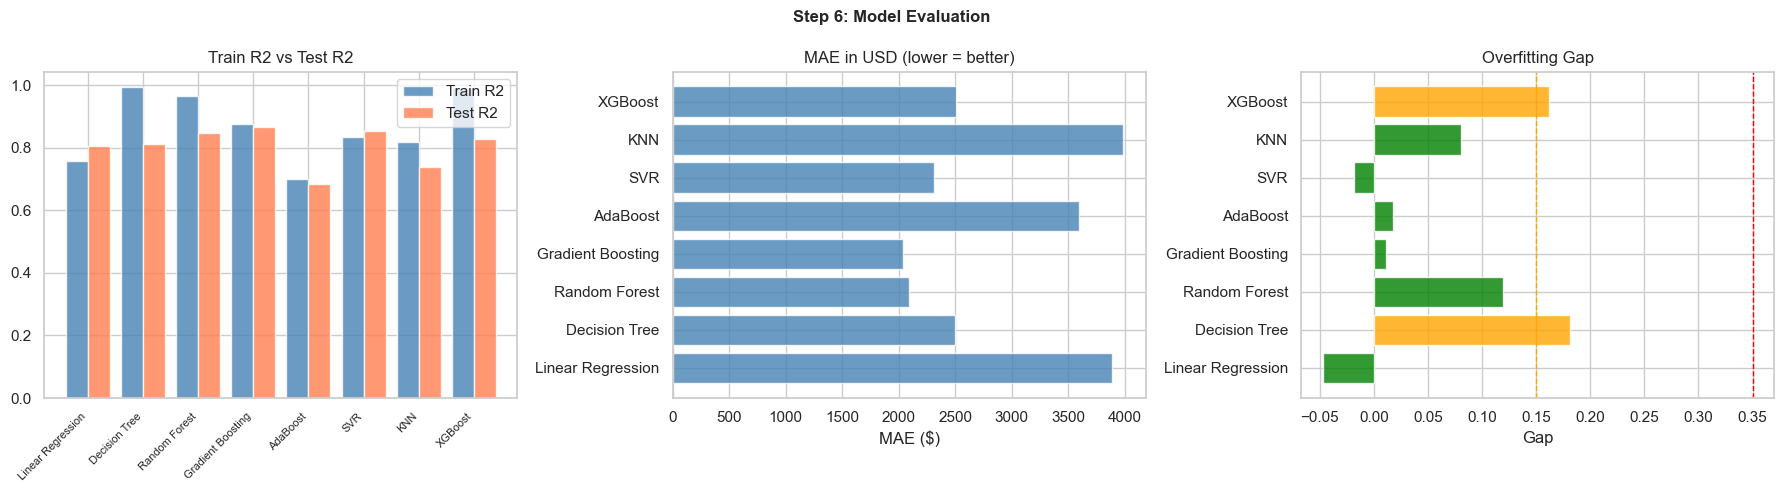

In [103]:
# Chart evaluation

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train vs Test R2
ax = axes[0]
x  = np.arange(len(results))
ax.bar(x - 0.2, results['Train R2'], 0.4, label='Train R2', color='steelblue', alpha=0.8)
ax.bar(x + 0.2, results['Test R2'],  0.4, label='Test R2',  color='coral',     alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=45, ha='right', fontsize=8)
ax.set_title('Train R2 vs Test R2')
ax.legend()

# MAE in USD
ax2 = axes[1]
ax2.barh(results['Model'], results['MAE ($)'], color='steelblue', alpha=0.8)
ax2.set_title('MAE in USD (lower = better)')
ax2.set_xlabel('MAE ($)')

# Overfitting Gap
ax3 = axes[2]
colors = ['red' if g > 0.35 else 'orange' if g > 0.15 else 'green'
          for g in results['Gap']]
ax3.barh(results['Model'], results['Gap'], color=colors, alpha=0.8)
ax3.axvline(0.15, color='orange', ls='--', lw=1)
ax3.axvline(0.35, color='red',    ls='--', lw=1)
ax3.set_title('Overfitting Gap')
ax3.set_xlabel('Gap')

plt.suptitle('Step 6: Model Evaluation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('step6_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

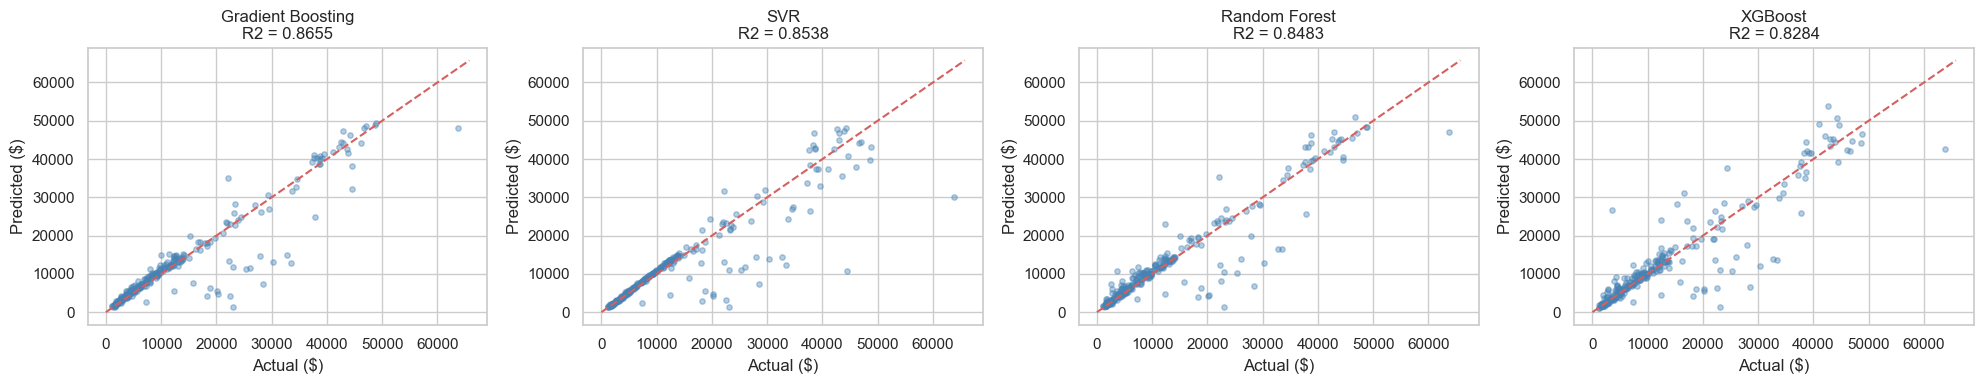

In [104]:
# Actual vs Predicted-Top4

top4  = results.nlargest(4, 'Test R2')['Model'].tolist()
yt_d  = np.expm1(y_test.values)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, name in zip(axes, top4):
    yp_d = np.expm1(models[name].predict(X_test))
    ax.scatter(yt_d, yp_d, alpha=0.4, s=15, color='steelblue')
    lims = [0, max(yt_d.max(), yp_d.max()) + 2000]
    ax.plot(lims, lims, 'r--', lw=1.5)
    r2_val = results.loc[results['Model'] == name, 'Test R2'].values[0]
    ax.set_title(f'{name}\nR2 = {r2_val:.4f}')
    ax.set_xlabel('Actual ($)')
    ax.set_ylabel('Predicted ($)')
plt.tight_layout()
plt.show()

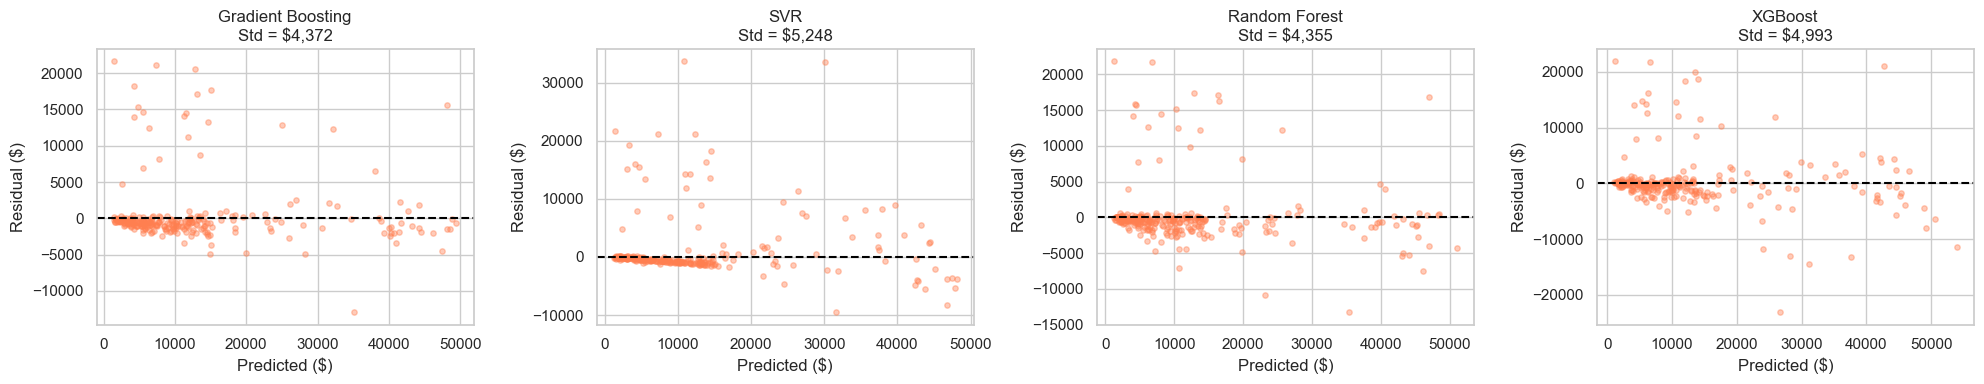

In [105]:
#Residual Plot

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, name in zip(axes, top4):
    yp_d  = np.expm1(models[name].predict(X_test))
    resid = yt_d - yp_d
    ax.scatter(yp_d, resid, alpha=0.4, s=15, color='coral')
    ax.axhline(0, color='black', ls='--', lw=1.5)
    ax.set_title(f'{name}\nStd = ${np.std(resid):,.0f}')
    ax.set_xlabel('Predicted ($)')
    ax.set_ylabel('Residual ($)')
plt.tight_layout()
plt.show()

### 7. Hyperparameter Tuning

    •	Use GridSearchCV or RandomizedSearchCV to optimize the best-performing models
    •	Document best parameters and improvement in performance
---

In [106]:
# Decision Tree

dt_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {'max_depth': [3,5,7,10], 'min_samples_split': [2,5,10], 'min_samples_leaf': [1,2,4]},
    cv=5, scoring='r2', n_jobs=-1
)
dt_gs.fit(X_train, y_train)
dt_best = dt_gs.best_estimator_

yp      = dt_best.predict(X_test)
dt_r2   = r2_score(y_test, yp)
dt_mae  = mean_absolute_error(np.expm1(y_test), np.expm1(yp))
base_r2 = results.loc[results['Model'] == 'Decision Tree', 'Test R2'].values[0]

print(f"Best Params  : {dt_gs.best_params_}")
print(f"CV R2        : {dt_gs.best_score_:.4f}")
print(f"Baseline R2  : {base_r2:.4f}  →  Tuned R2 : {dt_r2:.4f}  (Δ {dt_r2 - base_r2:+.4f})")
print(f"MAE          : ${dt_mae:,.2f}")

Best Params  : {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
CV R2        : 0.8082
Baseline R2  : 0.8132  →  Tuned R2 : 0.8502  (Δ +0.0370)
MAE          : $2,262.87


In [107]:
# Gradient Boost

gb_rs = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    {'n_estimators': [100,200], 'learning_rate': [0.05,0.1,0.2],
     'max_depth': [3,4,5], 'subsample': [0.8,0.9,1.0]},
    n_iter=15, cv=5, scoring='r2', random_state=42, n_jobs=-1
)
gb_rs.fit(X_train, y_train)
gb_best = gb_rs.best_estimator_

yp      = gb_best.predict(X_test)
gb_r2   = r2_score(y_test, yp)
gb_mae  = mean_absolute_error(np.expm1(y_test), np.expm1(yp))
base_r2 = results.loc[results['Model'] == 'Gradient Boosting', 'Test R2'].values[0]

print(f"Best Params  : {gb_rs.best_params_}")
print(f"CV R2        : {gb_rs.best_score_:.4f}")
print(f"Baseline R2  : {base_r2:.4f}  →  Tuned R2 : {gb_r2:.4f}  (Δ {gb_r2 - base_r2:+.4f})")
print(f"MAE          : ${gb_mae:,.2f}")

Best Params  : {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05}
CV R2        : 0.8169
Baseline R2  : 0.8655  →  Tuned R2 : 0.8693  (Δ +0.0038)
MAE          : $2,013.93


In [108]:
# XG Boost

xgb_rs = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    {'n_estimators': [100,200], 'learning_rate': [0.05,0.1,0.2],
     'max_depth': [3,4,5], 'subsample': [0.8,0.9,1.0]},
    n_iter=15, cv=5, scoring='r2', random_state=42, n_jobs=-1
)
xgb_rs.fit(X_train, y_train)
xgb_best = xgb_rs.best_estimator_

yp      = xgb_best.predict(X_test)
xgb_r2  = r2_score(y_test, yp)
xgb_mae = mean_absolute_error(np.expm1(y_test), np.expm1(yp))
base_r2 = results.loc[results['Model'] == 'XGBoost', 'Test R2'].values[0]

print(f"Best Params  : {xgb_rs.best_params_}")
print(f"CV R2        : {xgb_rs.best_score_:.4f}")
print(f"Baseline R2  : {base_r2:.4f}  →  Tuned R2 : {xgb_r2:.4f}  (Δ {xgb_r2 - base_r2:+.4f})")
print(f"MAE          : ${xgb_mae:,.2f}")

Best Params  : {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05}
CV R2        : 0.8192
Baseline R2  : 0.8284  →  Tuned R2 : 0.8673  (Δ +0.0389)
MAE          : $1,921.68


In [109]:
# Tuning Summary Table

tuned_models = {
    'Decision Tree (Tuned)':     dt_best,
    'Gradient Boosting (Tuned)': gb_best,
    'XGBoost (Tuned)':           xgb_best,
}

tuning_rows = []
for name, model in tuned_models.items():
    yp     = model.predict(X_test)
    yp_tr  = model.predict(X_train)
    tr     = r2_score(y_train, yp_tr)
    te     = r2_score(y_test,  yp)
    mae_d  = mean_absolute_error(np.expm1(y_test),  np.expm1(yp))
    rmse_d = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(yp)))
    tuning_rows.append({'Model': name, 'Train R2': round(tr,4), 'Test R2': round(te,4),
                        'MAE ($)': round(mae_d,2), 'RMSE ($)': round(rmse_d,2)})

pd.DataFrame(tuning_rows)

,Model,Train R2,Test R2,MAE ($),RMSE ($)
0,Decision Tree (Tuned),0.8445,0.8502,2262.87,4452.24
1,Gradient Boosting (Tuned),0.8807,0.8693,2013.93,4397.17
2,XGBoost (Tuned),0.8679,0.8673,1921.68,4269.07


### 8. Model Comparison Table

In [110]:
all_rows = rows.copy()

for name, model in tuned_models.items():
    yp     = model.predict(X_test)
    yp_tr  = model.predict(X_train)
    tr     = r2_score(y_train, yp_tr)
    te     = r2_score(y_test,  yp)
    n, p   = len(X_test), X_test.shape[1]
    ar2    = 1 - (1 - te) * (n - 1) / (n - p - 1)
    mae    = mean_absolute_error(y_test, yp)
    mse    = mean_squared_error(y_test,  yp)
    rmse   = np.sqrt(mse)
    mae_d  = mean_absolute_error(np.expm1(y_test),  np.expm1(yp))
    rmse_d = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(yp)))
    all_rows.append({'Model': name, 'Train R2': round(tr,4), 'Test R2': round(te,4),
        'Adj R2': round(ar2,4), 'MAE': round(mae,4), 'MSE': round(mse,4),
        'RMSE': round(rmse,4), 'MAE ($)': round(mae_d,2), 'RMSE ($)': round(rmse_d,2),
        'Gap': round(tr-te,4), 'Overfit': overfit_label(tr-te)})

comparison = (pd.DataFrame(all_rows)
                .sort_values('Test R2', ascending=False)
                .reset_index(drop=True))
comparison

,Model,Train R2,Test R2,Adj R2,MAE,MSE,RMSE,MAE ($),RMSE ($),Gap,Overfit
0,Gradient Boosting (Tuned),0.8807,0.8693,0.8653,0.1837,0.1175,0.3427,2013.93,4397.17,0.0113,Low
1,XGBoost (Tuned),0.8679,0.8673,0.8632,0.1831,0.1193,0.3454,1921.68,4269.07,0.0006,Low
2,Gradient Boosting,0.8768,0.8655,0.8613,0.1873,0.1209,0.3477,2035.42,4388.89,0.0113,NaN
3,SVR,0.8357,0.8538,0.8493,0.1641,0.1314,0.3625,2315.24,5340.02,-0.0181,NaN
4,Decision Tree (Tuned),0.8445,0.8502,0.8456,0.2194,0.1346,0.3669,2262.87,4452.24,-0.0058,Low
5,Random Forest,0.9672,0.8483,0.8436,0.1948,0.1364,0.3693,2087.51,4356.73,0.1189,NaN
6,XGBoost,0.9904,0.8284,0.8231,0.2118,0.1542,0.3927,2506.02,4997.43,0.1620,NaN
7,Decision Tree,0.9945,0.8132,0.8074,0.1833,0.1679,0.4097,2494.53,5682.98,0.1813,NaN
8,Linear Regression,0.7572,0.8047,0.7987,0.2697,0.1755,0.4189,3888.44,7814.06,-0.0475,NaN
9,KNN,0.8196,0.7391,0.7310,0.3104,0.2345,0.4843,3987.76,7816.64,0.0805,NaN


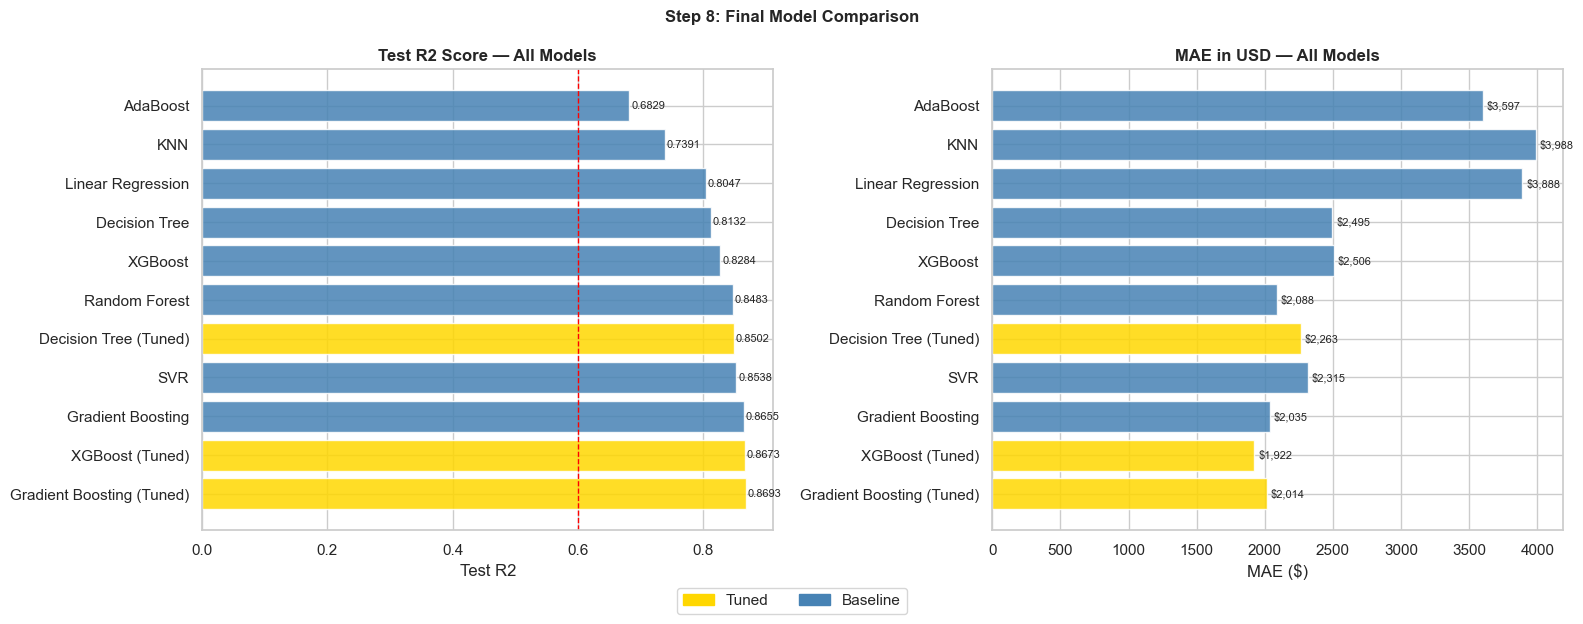

Best Model : Gradient Boosting (Tuned)
Test R2    : 0.8693
MAE ($)    : $2,013.93


In [111]:
# Final chart

import matplotlib.patches as mp

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bar_colors = ['gold' if 'Tuned' in m else 'steelblue' for m in comparison['Model']]

ax = axes[0]
bars = ax.barh(comparison['Model'], comparison['Test R2'], color=bar_colors, alpha=0.85)
ax.axvline(0.6, color='red', ls='--', lw=1)
ax.set_title('Test R2 Score — All Models', fontweight='bold')
ax.set_xlabel('Test R2')
for bar, v in zip(bars, comparison['Test R2']):
    ax.text(v + 0.003, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=8)

ax2 = axes[1]
bars2 = ax2.barh(comparison['Model'], comparison['MAE ($)'], color=bar_colors, alpha=0.85)
ax2.set_title('MAE in USD — All Models', fontweight='bold')
ax2.set_xlabel('MAE ($)')
for bar, v in zip(bars2, comparison['MAE ($)']):
    ax2.text(v + 30, bar.get_y() + bar.get_height()/2,
             f'${v:,.0f}', va='center', fontsize=8)

legend = [mp.Patch(color='gold',     label='Tuned'),
          mp.Patch(color='steelblue', label='Baseline')]
fig.legend(handles=legend, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.04))
plt.suptitle('Step 8: Final Model Comparison', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('step8_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

best = comparison.iloc[0]
print(f"Best Model : {best['Model']}")
print(f"Test R2    : {best['Test R2']}")
print(f"MAE ($)    : ${best['MAE ($)']:,.2f}")

In [112]:
# Best model

os.makedirs('models', exist_ok=True)

best_name = comparison.iloc[0]['Model']
best_obj  = tuned_models.get(best_name, models.get(best_name))

joblib.dump(best_obj,   'models/best_model.pkl')
joblib.dump(le_sex,     'models/le_sex.pkl')
joblib.dump(le_smoker,  'models/le_smoker.pkl')
joblib.dump(scaler,     'models/scaler.pkl')

print(f"Saved: {best_name} → models/best_model.pkl")

Saved: Gradient Boosting (Tuned) → models/best_model.pkl


**Streamlit app link**


https://medical-insurance-cost-predicter.streamlit.app/